# 1. Imports

In [36]:
import pandas as pd                 # Manejar DataFrames
from pathlib import Path            # Manejar rutas
import matplotlib.pyplot as plt     # Gráficos matplotlib
import seaborn as sns               # Gráficos seaborn
from matplotlib.patches import Wedge

# 2. Get data

Obtener dirección de carpetas necesarias

In [3]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


In [49]:
FIGURES_ROOT = PROJECT_ROOT / 'outputs' / 'figures'
print(FIGURES_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic\outputs\figures


Leer train y test

In [4]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'train.csv')

In [8]:
df_test = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'test.csv')

# 3. Initial analysis

Info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


Head

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# 4. Raw EDA

Esto será una exploración inicial de los datos sucios

Vamos a generar una constante para siempre organizar en orden 0-1, o sea "Not survived" y "Survived"

In [ ]:
SURVIVED_ORDER = [0, 1]

## 4.1 Survival distribution

Contar

In [15]:
count_survived = df['Survived'].value_counts()
count_survived

Survived
0    549
1    342
Name: count, dtype: int64

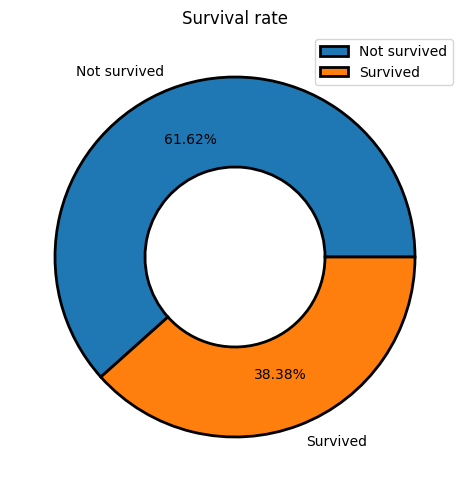

In [52]:
plt.pie(
    count_survived,
    labels=['Not survived', 'Survived'],
    autopct='%1.2f%%',
    pctdistance=0.7,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2,
        'width': 0.5
    }
)

plt.legend()
plt.tight_layout()
plt.title('Survival rate')

plt.savefig(FIGURES_ROOT / '01_survival_rate.png', bbox_inches='tight')
plt.show()

## 4.2 Survival distribution by Pclass

Contar por cada tipo de Pclass

In [53]:
count_pclass_1 = df[df['Pclass'] == 1]['Survived'].value_counts()
count_pclass_1

Survived
1    136
0     80
Name: count, dtype: int64

In [54]:
count_pclass_2 = df[df['Pclass'] == 2]['Survived'].value_counts()
count_pclass_2

Survived
0    97
1    87
Name: count, dtype: int64

In [55]:
count_pclass_3 = df[df['Pclass'] == 3]['Survived'].value_counts()
count_pclass_3

Survived
0    372
1    119
Name: count, dtype: int64

Visualizar cada proporción

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))


for i, 

# 5. Clean data

## 5.1 Age

Como desde ya tenemos un dataset con los datos de entrenamiento preseleccionados, rellenaremos los datos nulos de 'Age' con mediana.

In [11]:
median_age = df['Age'].median()
median_age

np.float64(28.0)

In [ ]:
df['Age'] = df['Age'].fillna()